In [ ]:
!pip install pandas numpy matplotlib scikit-learn nltk joblib streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 108.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 101.9 MB/s eta 0:00:00


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train/test split - stratified to preserve the ham/spam ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

# Define models to compare
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}
    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-score:  {f1:.4f}")

Train size: 4160
Test size: 1040

Naive Bayes:
  Accuracy:  0.9644
  Precision: 0.9802
  Recall:    0.7388
  F1-score:  0.8426

Logistic Regression:
  Accuracy:  0.9442
  Precision: 0.9750
  Recall:    0.5821
  F1-score:  0.7290

Linear SVM:
  Accuracy:  0.9740
  Precision: 0.9735
  Recall:    0.8209
  F1-score:  0.8907


In [ ]:
# Download and load the UCI SMS Spam Collection dataset
import pandas as pd

!wget -q https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip -O sms_spam.zip
!unzip -o -q sms_spam.zip

df_uci = pd.read_csv('SMSSpamCollection', sep='\t', header=None, names=['label', 'message'])

print("Shape:", df_uci.shape)
print(df_uci['label'].value_counts())
df_uci.head()

Shape: (5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df_nigeria = pd.read_csv('nigerian_sms_examples.csv')
df = pd.concat([df_uci, df_nigeria], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total messages: {len(df)}")
print(df['label'].value_counts())
df.head()

Total messages: 5603
label
ham     4841
spam     762
Name: count, dtype: int64


,label,message
0,ham,Isn't frnd a necesity in life? imagine urself ...
1,ham,Its a site to simulate the test. It just gives...
2,ham,"Alright if you're sure, let me know when you'r..."
3,ham,Did u fix the teeth?if not do it asap.ok take ...
4,ham,Nothing will ever be easy. But don't be lookin...


Missing values:
 label      0
message    0
dtype: int64

Duplicate rows: 403


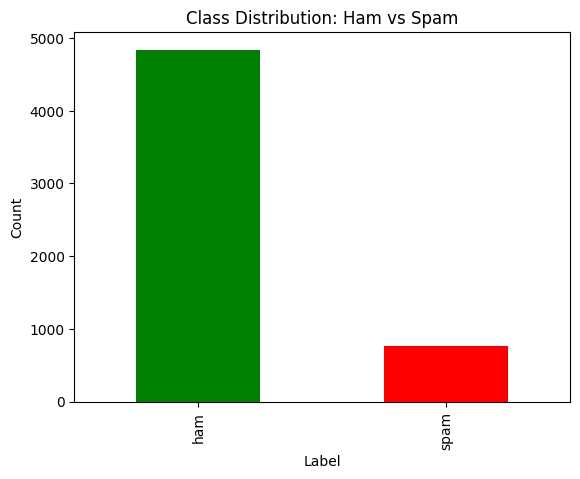


Message length stats:
         count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4841.0   71.488949  58.348479   2.0   33.0   53.0   93.0  910.0
spam    762.0  138.097113  28.902455  13.0  132.0  148.5  157.0  223.0


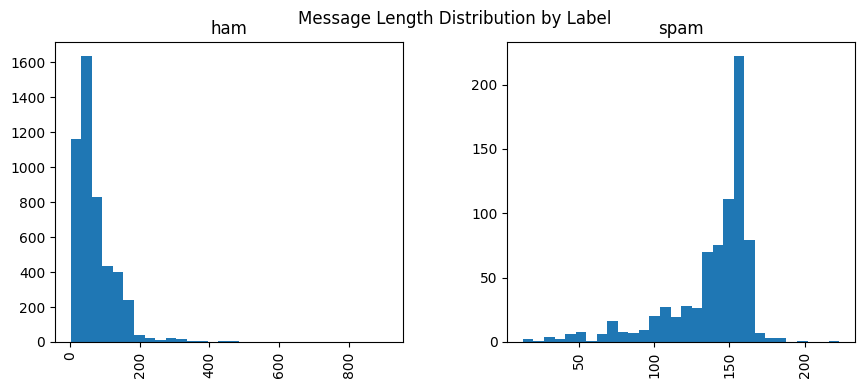

In [ ]:
import matplotlib.pyplot as plt

# Missing values
print("Missing values:\n", df.isnull().sum())

# Duplicate records
print("\nDuplicate rows:", df.duplicated().sum())

# Class distribution chart
df['label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Class Distribution: Ham vs Spam')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# Message length analysis
df['message_length'] = df['message'].apply(len)
print("\nMessage length stats:\n", df.groupby('label')['message_length'].describe())

df['message_length'].hist(by=df['label'], bins=30, figsize=(10,4))
plt.suptitle('Message Length Distribution by Label')
plt.show()

In [ ]:
# Remove duplicates
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)

print(f"Removed {before - after} duplicate rows")
print(f"New shape: {df.shape}")
print(df['label'].value_counts())

Removed 403 duplicate rows
New shape: (5200, 3)
label
ham     4532
spam     668
Name: count, dtype: int64


In [ ]:
from collections import Counter
import re

def get_top_words(messages, n=15):
    words = []
    for msg in messages:
        words.extend(re.findall(r'\b[a-z]+\b', msg.lower()))
    return Counter(words).most_common(n)

spam_words = get_top_words(df[df['label']=='spam']['message'])
ham_words = get_top_words(df[df['label']=='ham']['message'])

print("Top words in SPAM messages:")
for word, count in spam_words:
    print(f"  {word}: {count}")

print("\nTop words in HAM messages:")
for word, count in ham_words:
    print(f"  {word}: {count}")

Top words in SPAM messages:
  to: 610
  a: 336
  call: 313
  you: 273
  your: 259
  free: 195
  for: 189
  the: 185
  now: 168
  or: 159
  u: 147
  is: 146
  txt: 134
  from: 126
  on: 122

Top words in HAM messages:
  i: 2794
  you: 1888
  to: 1482
  the: 1068
  a: 978
  u: 930
  and: 827
  in: 763
  me: 735
  my: 679
  it: 664
  is: 660
  that: 546
  for: 488
  of: 480


In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()                              # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)         # remove URLs
    text = re.sub(r'<.*?>', '', text)                  # remove HTML tags
    text = re.sub(r'[^a-z\s]', '', text)                # remove punctuation/numbers/emojis
    tokens = text.split()                               # tokenize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]  # remove stopwords + lemmatize
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(clean_text)

print(df[['message', 'clean_message']].head(10))

LookupError: 
**********************************************************************
  Resource [93mstopwords[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('stopwords')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mcorpora/stopwords[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(clean_text)

print(df[['message', 'clean_message']].head(10))

                                             message  \
0  Isn't frnd a necesity in life? imagine urself ...   
1  Its a site to simulate the test. It just gives...   
2  Alright if you're sure, let me know when you'r...   
3  Did u fix the teeth?if not do it asap.ok take ...   
4  Nothing will ever be easy. But don't be lookin...   
5  Thought we could go out for dinner. I'll treat...   
6  Can come my room but cannot come my house cos ...   
7  Get the official ENGLAND poly ringtone or colo...   
8  Sppok up ur mob with a Halloween collection of...   
9      Thank you. do you generally date the brothas?   

                                       clean_message  
0  isnt frnd necesity life imagine urself witout ...  
1  site simulate test give tough question test re...  
2          alright youre sure let know youre leaving  
3                     u fix teethif asapok take care  
4  nothing ever easy dont looking reason take ris...  
5          thought could go dinner ill treat seem ok 

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF converts text into numerical vectors based on word importance
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['clean_message'])
y = df['label'].map({'ham': 0, 'spam': 1})  # convert labels to 0/1

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)
print("\nSample feature names:", tfidf.get_feature_names_out()[:20])

Feature matrix shape: (5200, 3000)
Labels shape: (5200,)

Sample feature names: ['aah' 'abi' 'ability' 'abiola' 'abj' 'able' 'abt' 'abta' 'aburo' 'ac'
 'academic' 'acc' 'accept' 'access' 'accident' 'accidentally' 'account'
 'ache' 'across' 'action']


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train/test split - stratified to preserve the ham/spam ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

# Define models to compare
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}
    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-score:  {f1:.4f}")

Train size: 4160
Test size: 1040

Naive Bayes:
  Accuracy:  0.9644
  Precision: 0.9802
  Recall:    0.7388
  F1-score:  0.8426

Logistic Regression:
  Accuracy:  0.9442
  Precision: 0.9750
  Recall:    0.5821
  F1-score:  0.7290

Linear SVM:
  Accuracy:  0.9740
  Precision: 0.9735
  Recall:    0.8209
  F1-score:  0.8907


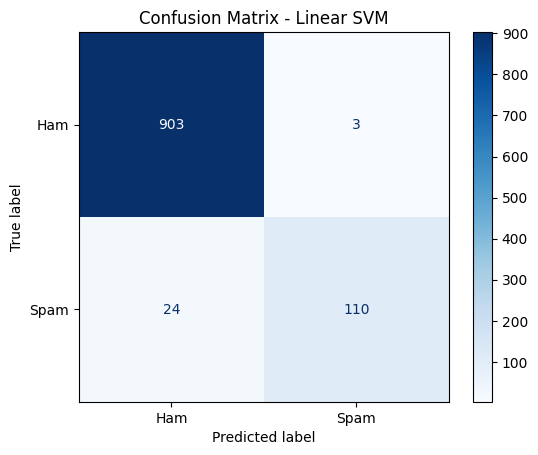

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       906
        Spam       0.97      0.82      0.89       134

    accuracy                           0.97      1040
   macro avg       0.97      0.91      0.94      1040
weighted avg       0.97      0.97      0.97      1040



In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Retrain SVM (already trained above, but let's isolate it clearly)
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Linear SVM')
plt.show()

# Full classification report
print(classification_report(y_test, y_pred_svm, target_names=['Ham', 'Spam']))

In [13]:
import numpy as np

# Get the original test set messages (not the TF-IDF vectors)
test_indices = X_test.indices if hasattr(X_test, 'indices') else None
# Recreate a proper mapping using the split
_, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=y)

test_df = test_df.reset_index(drop=True)
test_df['predicted'] = y_pred_svm

# False Negatives: actual spam, predicted ham
fn = test_df[(test_df['label']=='spam') & (test_df['predicted']==0)]
print("=== FALSE NEGATIVES (missed spam) ===")
for msg in fn['message']:
    print("-", msg[:100])

# False Positives: actual ham, predicted spam
fp = test_df[(test_df['label']=='ham') & (test_df['predicted']==1)]
print("\n=== FALSE POSITIVES (safe flagged as spam) ===")
for msg in fp['message']:
    print("-", msg[:100])

=== FALSE NEGATIVES (missed spam) ===
- Hi if ur lookin 4 saucy daytime fun wiv busty married woman Am free all next week Chat now 2 sort ti
- I don't know u and u don't know me. Send CHAT to 86688 now and let's find each other! Only 150p/Msg 
- Money i have won wining number 946 wot do i do next
- You won't believe it but it's true. It's Incredible Txts! Reply G now to learn truly amazing things 
- Hi ya babe x u 4goten bout me?' scammers getting smart..Though this is a regular vodafone no, if you
- 1000's of girls many local 2 u who r virgins 2 this & r ready 2 4fil ur every sexual need. Can u 4fi
- XCLUSIVE@CLUBSAISAI 2MOROW 28/5 SOIREE SPECIALE ZOUK WITH NICHOLS FROM PARIS.FREE ROSES 2 ALL LADIES
- A link to your picture has been sent. You can also use http://alto18.co.uk/wave/wave.asp?o=44345
- Burger King - Wanna play footy at a top stadium? Get 2 Burger King before 1st Sept and go Large or S
- SMS. ac Blind Date 4U!: Rodds1 is 21/m from Aberdeen, United Kingdom. Check Him out ht

In [14]:
import joblib

# Save the trained SVM model and TF-IDF vectorizer
joblib.dump(svm_model, 'fraud_sms_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Model and vectorizer saved successfully!")
print("Files created: fraud_sms_model.pkl, tfidf_vectorizer.pkl")

Model and vectorizer saved successfully!
Files created: fraud_sms_model.pkl, tfidf_vectorizer.pkl
